# DESI QSO FRACCOV

In [1]:
import fitsio
import numpy as np
import healpy as hp
import pandas as pd
import seaborn as sns
from astropy.table import Table, vstack, MaskedColumn
import matplotlib.pyplot as plt
%matplotlib inline

from Simulation.simulMap import *
from Simulation.mappers import DensityMapper, FracCovMapper

In [2]:
nside = 128
npix= hp.nside2npix(nside)
area_deg2 = hp.nside2pixarea(nside, degrees=True)
print("Number of pixels = {}".format(npix))
print("Surface of a pixel = {} deg^2".format(area_deg2))

Number of pixels = 196608
Surface of a pixel = 0.2098234113027917 deg^2


## FRACCOV

In [3]:
#File name:
DIR = "data/Data DESI/"
FILE_DR1 = DIR + "dr1-main-dark.fits"

#Reading file:
DR1_Mapper = FracCovMapper.read(FILE_DR1, nest=True)
DR1_Mapper.get_nside(nside)
DR1_Mapper._set_instance_settingsPlot(unit = "FRACCOV for QSO") #to customize the unit of plots.
DR1_Mapper.table

HPXPIXEL,RA,DEC,TILEIDS,EXPFACS,NPASS,EXPFAC_MEAN,NTILE,FRACCOV,HealPIX_128
int64,float64,float64,int64[7],float64[7],int64,float64,float64,float64,int64
0,45.0,0.03730194242227469,0 .. 11054,0.0 .. 1.8845893455658547,5,1.9640771653269895,5.0,0.7142857142857143,0
1,45.04394531249999,0.07460390065516265,0 .. 11054,0.0 .. 1.8845893455658547,5,1.9640771653269895,5.0,0.7142857142857143,0
2,44.9560546875,0.07460390065516265,0 .. 11054,0.0 .. 1.8845893455658547,5,1.9640771653269895,5.0,0.7142857142857143,0
3,45.0,0.11190589050941924,0 .. 11054,0.0 .. 1.8845893455658547,5,1.9640771653269895,5.0,0.7142857142857143,0
4,45.08789062499999,0.11190589050941924,0 .. 11054,0.0 .. 1.8845893455658547,5,1.9640771653269895,5.0,0.7142857142857143,0
5,45.13183593749999,0.14920792779581404,0 .. 0,0.0 .. 0.0,4,1.983949120267273,4.0,0.6666666666666666,0
6,45.04394531249999,0.14920792779581404,0 .. 11054,0.0 .. 1.8845893455658547,5,1.9640771653269895,5.0,0.7142857142857143,0
7,45.08789062499999,0.18651002832535823,0 .. 0,0.0 .. 0.0,4,1.983949120267273,4.0,0.6666666666666666,0
8,44.912109375,0.11190589050941924,0 .. 11054,0.0 .. 1.8845893455658547,5,1.9640771653269895,5.0,0.7142857142857143,0


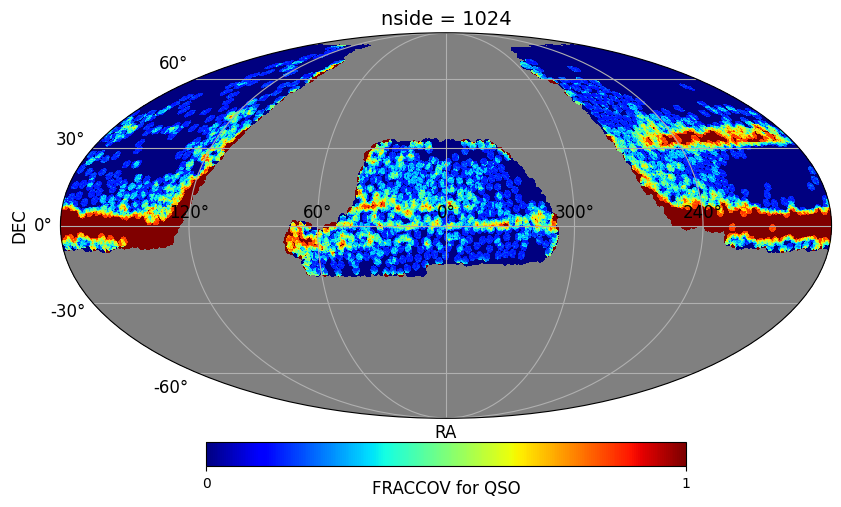

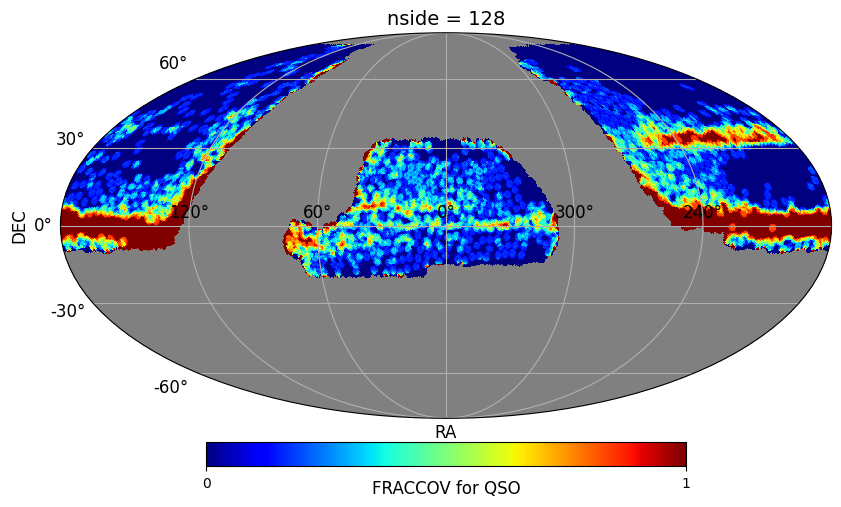

In [4]:
DR1_Mapper.plot(title = f"nside = {DR1_Mapper.nsideOriginal}")
DR1_Mapper.plot(use_map = "nside", title = f"nside = {DR1_Mapper.nside}")

## Density

In [5]:
#File names:
FILE_NGC = DIR + "QSO_NGC_clustering.dat.fits"
FILE_SGC = DIR + "QSO_SGC_clustering.dat.fits"

#Reading files:
NGC_Mapper = DensityMapper.read(FILE_NGC, nside=nside, nest=True)
SGC_Mapper = DensityMapper.read(FILE_SGC, nside=nside, nest=True)
BGS_Mapper = NGC_Mapper.add(SGC_Mapper)
BGS_Mapper.table

TARGETID,NTILE,RA,DEC,PHOTSYS,Z,FRAC_TLOBS_TILES,WEIGHT_ZFAIL,WEIGHT_RF,BITWEIGHTS,PROB_OBS,WEIGHT_SYS,WEIGHT,WEIGHT_COMP,NX,WEIGHT_FKP
,,deg,deg,,,,,,,,,,,,
int64,int64,float64,float64,bytes1,float64,float64,float64,float64,int64[2],float64,float64,float64,float64,float64,float64
39627540901396635,1,159.24049207286527,-10.157311765959316,S,3.31353326666703,0.9747126436781609,1.0,0.9201403959075474,-1 .. -1,1.0,0.9201403959075474,0.7151357903795799,1.0,2.447879382530844e-06,0.9855253173679175
39627546840533492,1,158.63403463390813,-9.88258718935724,S,3.060108483008445,0.9747126436781609,1.0,0.9488140574458624,-1 .. -1,1.0,0.9488140574458624,0.7374210434762604,1.0,4.361994200942654e-06,0.9744955367198997
39627546844725753,1,158.73664897414398,-9.969939586395,S,2.541858124850623,0.9747126436781609,1.0,0.9488140574458624,-1 .. -1,1.0,0.9488140574458624,0.7374210434762604,1.0,1.0418531095218907e-05,0.9411665614806044
39627546848919608,1,158.95954631762686,-9.918830242767902,S,3.0791403351173816,0.9747126436781609,1.0126360654830933,0.9835624133635871,-1 .. -1,1.0,0.9835624133635871,0.7740869234925823,1.0,4.361994200942654e-06,0.9744955367198997
39627546848920015,1,158.9834451646182,-9.940326955691557,S,2.1183562737081045,0.9747126436781609,1.0,0.9835624133635871,-1 .. -1,1.0,0.9835624133635871,0.7644275667026461,1.0,1.872299525820529e-05,0.8990073391158527
39627546848921143,1,159.04734322663907,-9.942785828668026,S,1.3605934952612553,0.9747126436781609,1.0097328424453735,0.9885456821502936,-1 .. -1,1.0,0.9885456821502936,0.7757783261624652,1.0,2.5976158971824955e-05,0.8651589599263295
39627546848921614,1,159.07642532181774,-9.943104780472032,S,1.2436983617416455,0.9747126436781609,1.0,1.010660874479752,-1 .. -1,1.0,1.010660874479752,0.7854885694524114,1.0,2.5962721625169074e-05,0.8652193112619179
39627546848922860,1,159.1458229485638,-10.099793205114715,S,1.104592428700879,0.9747126436781609,1.0,1.0297096071899399,-1 .. -1,1.0,1.0297096071899399,0.8002932998859595,1.0,2.3079897197951834e-05,0.8783646105211212


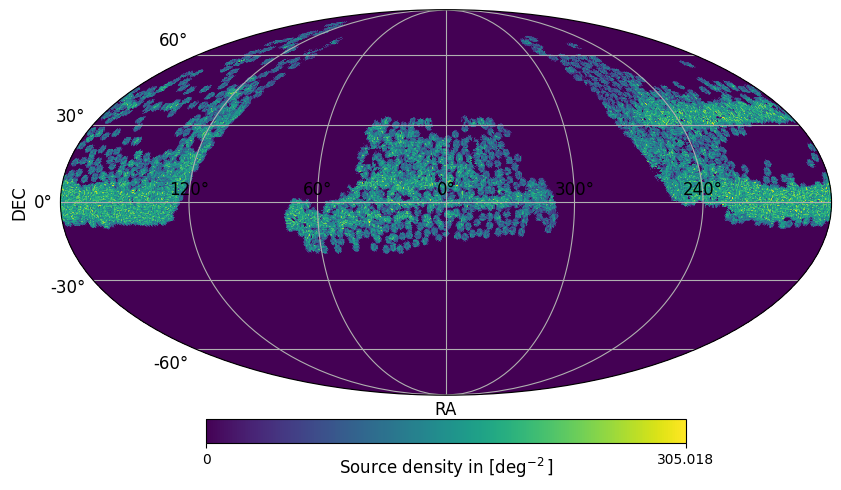

In [6]:
BGS_Mapper.plot(use_map='')

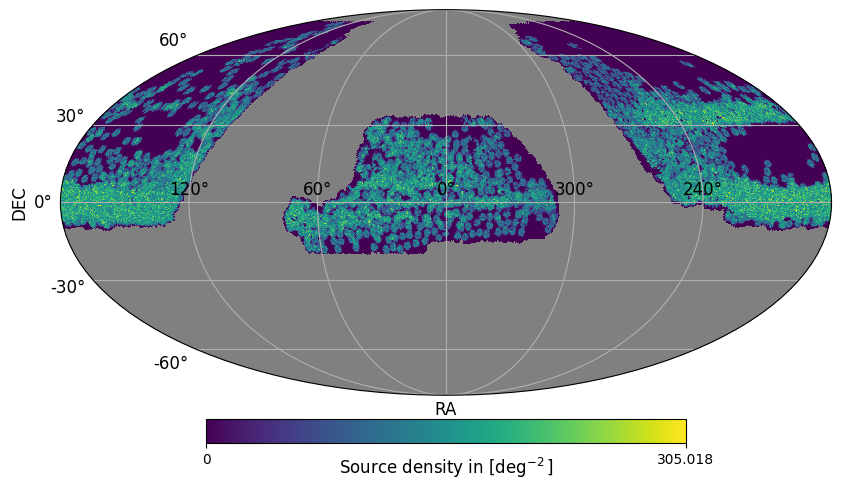

In [7]:
mask = np.array(DR1_Mapper.mask_FRACCOVnside)
BGS_Mapper.set_mask(mask)
BGS_Mapper.plot(use_map='Masked')

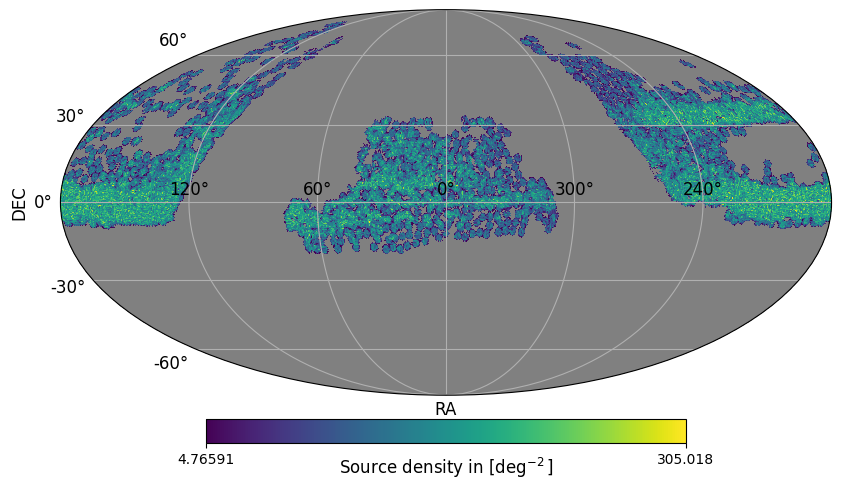

In [8]:
BGS_Mapper.set_mask()
BGS_Mapper.plot("Masked")

┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 2.492e+06 (χ²/ndof = 12.7) │              Nfcn = 406              │
│ EDM = 9.16e-07 (Goal: 0.0002)    │           time = 12.1 sec            │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│      No parameters at limit      │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate          │
└──────────────────────────────────┴──────────────────────────────────────┘
┌───┬──────┬───────────┬───────────┬────────────┬────────────┬─────────┬─────────┬───────┐
│   │ Name │   Value   │ Hesse Err │ Minos Err- │ Minos Err+ │ Limit-  │ Limit+  │ Fixed │
├───┼──────┼───────────┼───────────┼────────────┼────────────┼─────────┼─────────┼───────┤
│ 0 │ M    │   79.93   │   0.05    │   -0.05    │    0.05    │    0    │         │       │
│ 1 │ A    │  0.6125   │  0.0013   │  -0.0013   │   0.0013   │    0    │    1    │       │
│ 2 │ ra   │  186.22   │   0.24    │   -0.24    │    0.24    │    0    │   360   │       │
│ 3 │ dec  │  -70.06   │   0.06    │   -0.06    │    0.06    │   -90   │   90    │       │
└───┴──────┴───────────┴───────────┴────────────┴────────────┴─────────┴─────────┴───────┘
┌──────────┬───────────────────────┬───────────────────────┬───────────────────────┬───────────────────────┐
│          │           M           │           A           │          ra           │          dec          │
├──────────┼───────────┬───────────┼───────────┬───────────┼───────────┬───────────┼───────────┬───────────┤
│  Error   │   -0.05   │   0.05    │  -0.0013  │  0.0013   │   -0.24   │   0.24    │   -0.06   │   0.06    │
│  Valid   │   True    │   True    │   True    │   True    │   True    │   True    │   True    │   True    │
│ At Limit │   False   │   False   │   False   │   False   │   False   │   False   │   False   │   False   │
│ Max FCN  │   False   │   False   │   False   │   False   │   False   │   False   │   False   │   False   │
│ New Min  │   False   │   False   │   False   │   False   │   False   │   False   │   False   │   False   │
└──────────┴───────────┴───────────┴───────────┴───────────┴───────────┴───────────┴───────────┴───────────┘
┌─────┬─────────────────────────────────────┐
│     │        M        A       ra      dec │
├─────┼─────────────────────────────────────┤
│   M │  0.00271  34.2e-6   0.0005  -0.0009 │
│   A │  34.2e-6 1.62e-06  39.1e-6 -18.6e-6 │
│  ra │   0.0005  39.1e-6   0.0571   -0.000 │
│ dec │  -0.0009 -18.6e-6   -0.000   0.0039 │
└─────┴─────────────────────────────────────┘

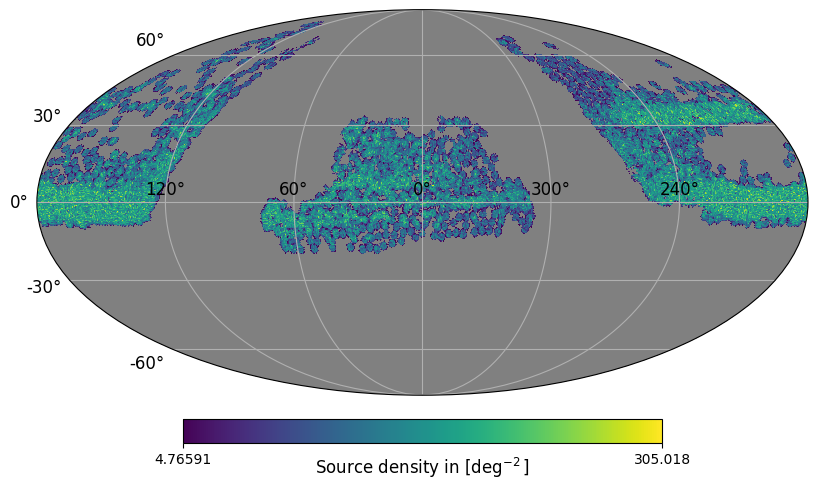

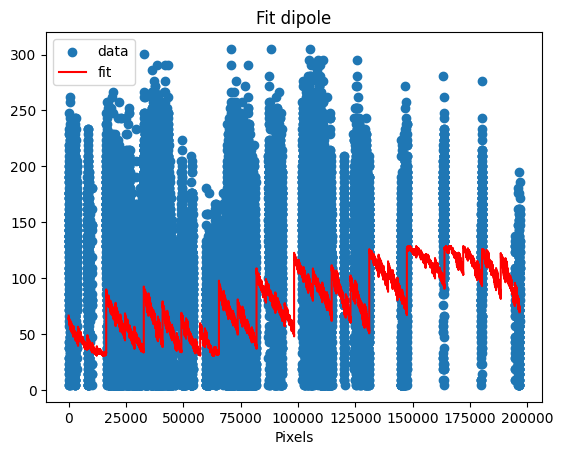

In [9]:
map = BGS_Mapper.mapMasked.copy()
hp.projview(map, unit="Source density in $[\deg^{-2}]$", nest=True, graticule=True, graticule_labels=True)

model = lambda map, M, A, ra, dec : apply_dipole_MD(map, M, A, ra, dec, nest=True, cut_masked=True, frame='icrs', contrast=False)
init =  (1000, 1, 100, 40)
names = ("M", "A", "ra", "dec")
m = fit_dipole_err(model, map, init, names, bounds=([0, 0, 0, -90], [np.inf, 1, 360, 90]))
m

## FRACCOV cut

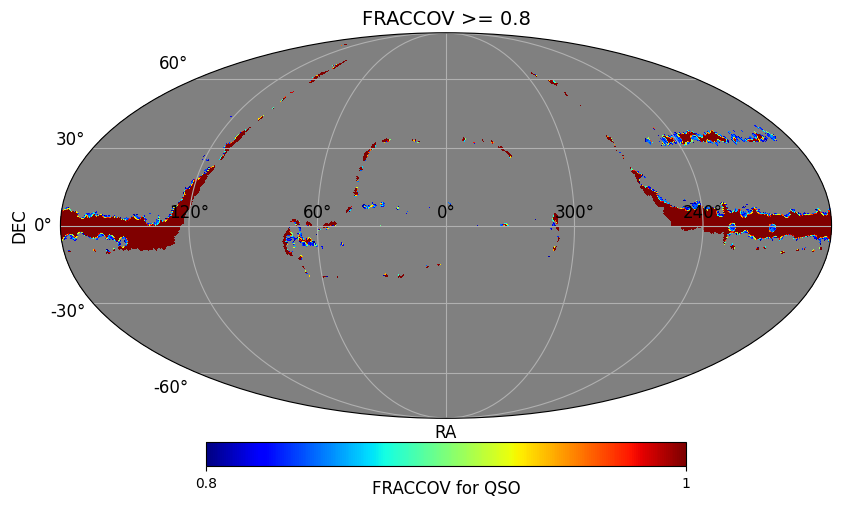

In [10]:
frac_min = 0.8
DR1_Mapper.cut_FracCov(frac_min=frac_min)
DR1_Mapper.plot(use_map="cut", title = f"FRACCOV >= {frac_min}")

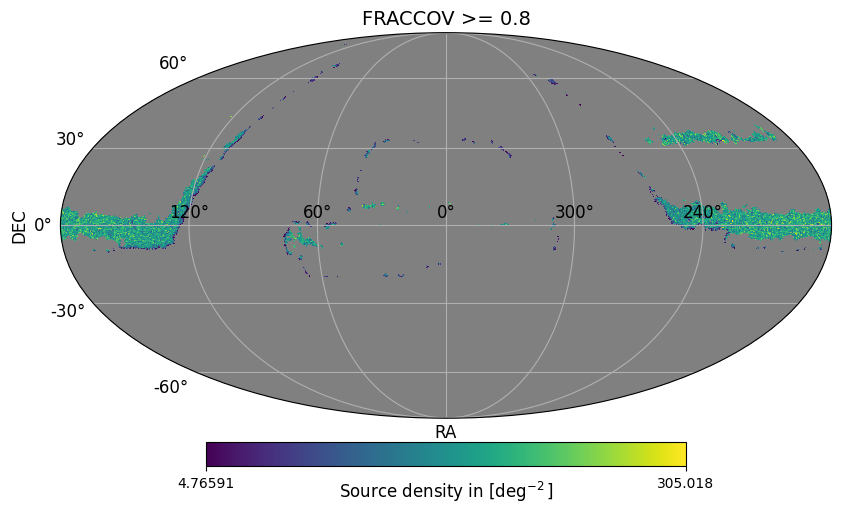

In [11]:
BGS_Mapper.set_cutMask(DR1_Mapper.FRACCOVcut.mask)
BGS_Mapper.plot(use_map='Cut', title=f'FRACCOV >= {frac_min}')

┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 3.933e+05 (χ²/ndof = 2.0)  │              Nfcn = 586              │
│ EDM = 4.02e-08 (Goal: 0.0002)    │           time = 18.0 sec            │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│     SOME parameters at limit     │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │     Covariance FORCED pos. def.      │
└──────────────────────────────────┴──────────────────────────────────────┘
┌───┬──────┬───────────┬───────────┬────────────┬────────────┬─────────┬─────────┬───────┐
│   │ Name │   Value   │ Hesse Err │ Minos Err- │ Minos Err+ │ Limit-  │ Limit+  │ Fixed │
├───┼──────┼───────────┼───────────┼────────────┼────────────┼─────────┼─────────┼───────┤
│ 0 │ M    │  121.096  │   0.007   │   -0.007   │   0.007    │    0    │         │       │
│ 1 │ A    │ 450.66e-3 │  0.18e-3  │  -0.18e-3  │  0.18e-3   │    0    │    1    │       │
│ 2 │ ra   │    0.4    │   296.1   │    -0.4    │   296.1    │    0    │   360   │       │
│ 3 │ dec  │-89.999999999987│0.000578603664│-0.000000000013│0.000578603664│   -90   │   90    │       │
└───┴──────┴───────────┴───────────┴────────────┴────────────┴─────────┴─────────┴───────┘
┌──────────┬───────────────────────┬───────────────────────┬───────────────────────┬───────────────────────┐
│          │           M           │           A           │          ra           │          dec          │
├──────────┼───────────┬───────────┼───────────┬───────────┼───────────┬───────────┼───────────┬───────────┤
│  Error   │  -0.007   │   0.007   │ -0.18e-3  │  0.18e-3  │   -0.4    │   296.1   │ -0.013e-9 │578603.664e-9│
│  Valid   │   False   │   False   │   False   │   False   │   True    │   False   │   True    │   False   │
│ At Limit │   False   │   False   │   False   │   False   │   True    │   False   │   True    │   False   │
│ Max FCN  │   False   │   False   │   False   │   False   │   False   │   False   │   False   │   False   │
│ New Min  │   True    │   True    │   True    │   True    │   False   │   True    │   False   │   True    │
└──────────┴───────────┴───────────┴───────────┴───────────┴───────────┴───────────┴───────────┴───────────┘
┌─────┬─────────────────────────────────────────────────────────────────────────────────┐
│     │                   M                   A                  ra                 dec │
├─────┼─────────────────────────────────────────────────────────────────────────────────┤
│   M │            4.38e-05            0.001e-6           -14.83e-3           0.023e-12 │
│   A │            0.001e-6            3.28e-08         1.619541e-3          -0.003e-12 │
│  ra │           -14.83e-3         1.619541e-3            1.28e+10 -19.756538276224e-3 │
│ dec │           0.023e-12          -0.003e-12 -19.756538276224e-3            3.06e-14 │
└─────┴─────────────────────────────────────────────────────────────────────────────────┘

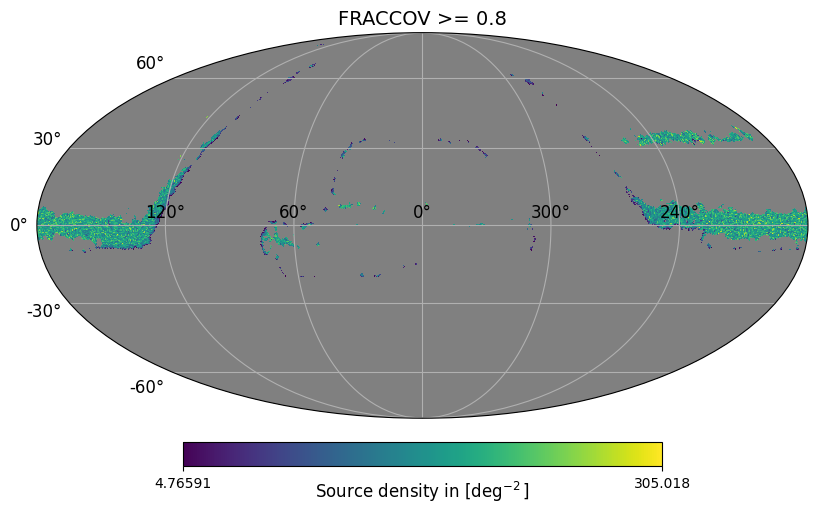

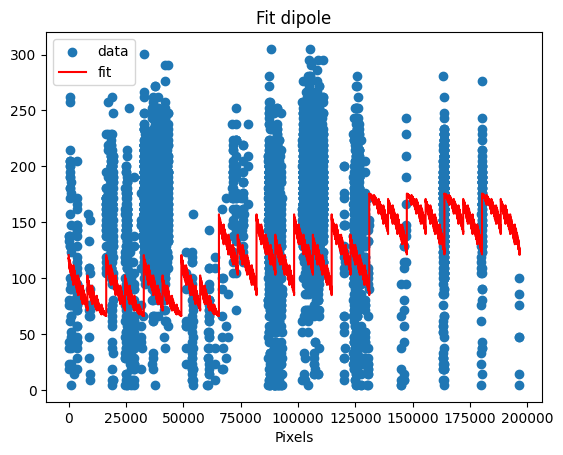

In [12]:
map = BGS_Mapper.mapCut
hp.projview(map, unit="Source density in $[\deg^{-2}]$", nest=True, graticule=True, graticule_labels=True, title=f'FRACCOV >= {frac_min}')

model = lambda map, M, A, ra, dec : apply_dipole_MD(map, M, A, ra, dec, nest=True, cut_masked=True, frame='icrs', contrast=False)
init =  (2000, 1, 100, 40)
names = ("M", "A", "ra", "dec")
m = fit_dipole_err(model, map, init, names, bounds=([0, 0, 0, -90], [np.inf, 1, 360, 90]))
m

## Density count > min and FRACCOV > 0.9

Attribut FRACCOVcut already existed and has been replaced.


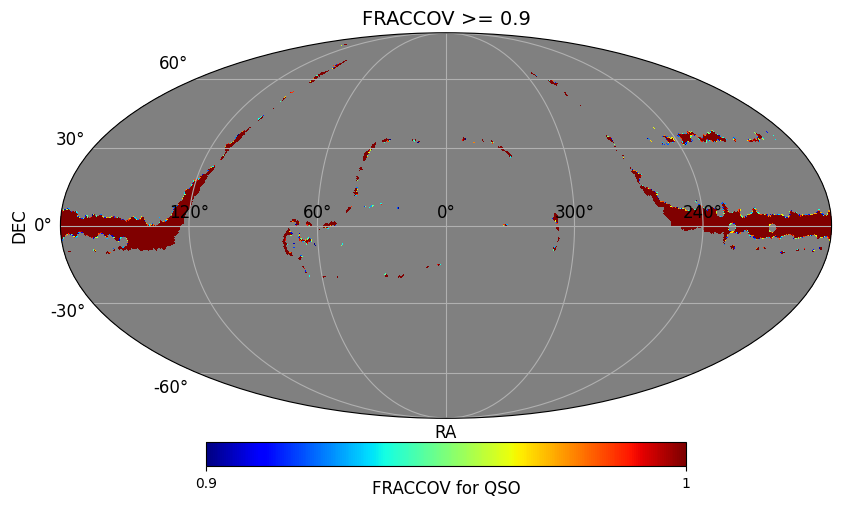

In [13]:
frac_min = 0.9
DR1_Mapper.cut_FracCov(frac_min=frac_min)
DR1_Mapper.plot(use_map="cut", title = f"FRACCOV >= {frac_min}")

Attribut map has no attribut mask. Using mask from mapMasked instead.
Attribut mapCut already existed and has been replaced.


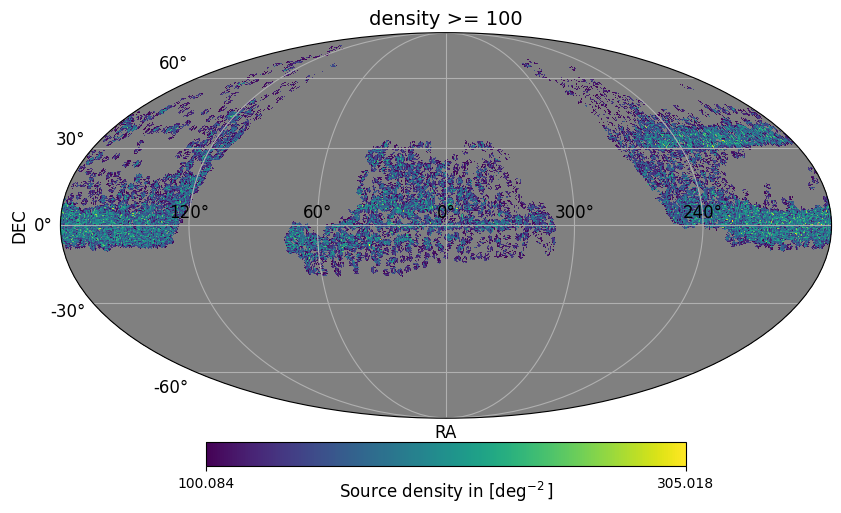

In [14]:
count_min = 100
BGS_Mapper.select_bounds(map_min=count_min)
BGS_Mapper.plot(use_map="Cut", title = f"density >= {count_min}")

In [ ]:
BGS_Mapper.set_cutMask(DR1_Mapper.FRACCOVcut.mask, fromMap="Cut")
BGS_Mapper.plot(use_map="Cut", title=f'FRACCOV >= {frac_min} and density >= {count_min}')

Attribut mapCut already existed and has been replaced.
